<!--<badge>--><a href="https://colab.research.google.com/github/JoeChen322/Fintech/blob/main/recommend-system.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a><!--</badge>-->


In [1]:
import joblib
import gdown
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import tqdm
from pathlib import Path
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split

from sklearn.base import BaseEstimator, TransformerMixin

FIGURES_DIR = Path("figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

%config InlineBackend.figure_format = 'retina'

In [2]:
url = "https://drive.google.com/uc?id=1TiR645keulkG4pONLpVn-bO4elNBtNpX"
file_path = "Dataset2_Needs.xls"
gdown.download(url, file_path, quiet=False)
needs_df = pd.read_excel(file_path, sheet_name="Needs")
products_df = pd.read_excel(file_path, sheet_name="Products")
metadata_df = pd.read_excel(file_path, sheet_name="Metadata")

print("Needs shape:", needs_df.shape)
print("Products shape:", products_df.shape)
print("Metadata shape:", metadata_df.shape)

Downloading...
From: https://drive.google.com/uc?id=1TiR645keulkG4pONLpVn-bO4elNBtNpX
To: /Users/pengrao/Workspace/Fintech/Dataset2_Needs.xls
100%|██████████| 428k/428k [00:00<00:00, 8.07MB/s]


Needs shape: (5000, 10)
Products shape: (11, 3)
Metadata shape: (29, 2)


# Utils function


In [3]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    """
    Creates engineered features and filters columns based on the apple_feat_eng flag.
    """

    def __init__(self, apple_feat_eng=True):
        self.apple_feat_eng = apple_feat_eng

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_transformed = X.copy()

        # Create engineered features
        has_income = "Income" in X_transformed.columns
        has_wealth = "Wealth" in X_transformed.columns
        has_family = "FamilyMembers" in X_transformed.columns
        has_risk = "RiskPropensity" in X_transformed.columns
        has_edu = "FinancialEducation" in X_transformed.columns
        has_age = "Age" in X_transformed.columns

        if has_income and has_family:
            X_transformed["IncomePerFamilyMember"] = (
                X_transformed["Income"] / X_transformed["FamilyMembers"]
            )
        if has_wealth and has_family:
            X_transformed["WealthPerFamilyMember"] = (
                X_transformed["Wealth"] / X_transformed["FamilyMembers"]
            )
        if has_income and has_wealth:
            X_transformed["WealthIncomeRatio"] = (
                X_transformed["Wealth"] / X_transformed["Income"]
            )

        if has_risk and has_edu:
            X_transformed["RiskEducationInteraction"] = (
                X_transformed["RiskPropensity"] * X_transformed["FinancialEducation"]
            )

        if has_risk:
            wealth_col = (
                "Wealth_log" if "Wealth_log" in X_transformed.columns else "Wealth"
            )
            if wealth_col in X_transformed.columns:
                X_transformed["RiskWealthInteraction"] = (
                    X_transformed["RiskPropensity"] * X_transformed[wealth_col]
                )

        if has_age and has_risk:
            X_transformed["AgeRiskInteraction"] = (
                X_transformed["Age"] * X_transformed["RiskPropensity"]
            )

        if has_age:
            X_transformed["AgeSquared"] = X_transformed["Age"] ** 2
            X_transformed["Age_Under35"] = (X_transformed["Age"] < 35).astype(int)
            X_transformed["Age_35_54"] = (
                (X_transformed["Age"] >= 35) & (X_transformed["Age"] < 55)
            ).astype(int)
            X_transformed["Age_55_69"] = (
                (X_transformed["Age"] >= 55) & (X_transformed["Age"] < 70)
            ).astype(int)
            X_transformed["Age_70plus"] = (X_transformed["Age"] >= 70).astype(int)

        features_base = [
            "Age",
            "Gender",
            "FamilyMembers",
            "FinancialEducation",
            "RiskPropensity",
            "Wealth_log",
            "Income_log",
        ]

        features_engineered = [
            "Age",
            "Gender",
            "FamilyMembers",
            "FinancialEducation",
            "RiskPropensity",
            "IncomePerFamilyMember",
            "WealthPerFamilyMember",
            "WealthIncomeRatio",
            "RiskEducationInteraction",
            "RiskWealthInteraction",
            "AgeRiskInteraction",
            "AgeSquared",
            "Age_Under35",
            "Age_35_54",
            "Age_55_69",
            "Age_70plus",
        ]

        if self.apple_feat_eng:
            cols = [c for c in features_engineered if c in X_transformed.columns]
        else:
            cols = [c for c in features_base if c in X_transformed.columns]

        return X_transformed[cols]

In [4]:
class DataTransformer(BaseEstimator, TransformerMixin):
    """
    Cleans data by converting values to numeric and applying log transformations
    to skewed financial variables.
    """

    def __init__(self):
        pass

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X_transformed = X.copy()

        for col in X_transformed.columns:
            X_transformed[col] = pd.to_numeric(X_transformed[col], errors="coerce")

        # Apply log transformations to Wealth and Income
        cols_to_log = ["Income", "Wealth"]
        for col in cols_to_log:
            if col in X_transformed.columns:
                X_transformed[f"{col}_log"] = np.log1p(X_transformed[col])

        return X_transformed

# Load Best classifier


In [5]:
# Load the saved Random Forest models
best_income_model = joblib.load("best_income_model.pkl")
best_accum_model = joblib.load("best_accum_model.pkl")

# Get probability predictions for all clients using the loaded models
X_raw = needs_df.drop(
    columns=["IncomeInvestment", "AccumulationInvestment"], errors="ignore"
)

income_proba_all = best_income_model.predict_proba(X_raw)[:, 1]
accum_proba_all = best_accum_model.predict_proba(X_raw)[:, 1]

accum_proba = pd.Series(accum_proba_all, index=X_raw.index, name="P_acc")
income_proba = pd.Series(income_proba_all, index=X_raw.index, name="P_inc")

/Users/pengrao/Workspace/Fintech/.venv/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/pengrao/Workspace/Fintech/.venv/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeClassifier from version 1.6.1 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/Users/pengrao/Workspace/Fintech/.venv/lib/python3.11/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator Rand

# Recommendation Systems

This section adds SVD and autoencoder recommenders built from a client-product interaction matrix.


## SVD


SVD (Singular Value Decomposition) recommends items by factorizing the user-item interaction matrix $R$ into low-dimensional latent factors that capture hidden preferences and item characteristics.

In practice, we approximate:

$$
R \approx U_k \Sigma_k V_k^T
$$

where $k$ is the number of retained latent dimensions.

The predicted preference score for user $u$ and item $i$ is reconstructed from these latent factors (dot product in latent space). Higher reconstructed scores indicate stronger recommendation relevance.

Why this works: SVD compresses noisy sparse interactions into a compact structure, keeping the strongest collaborative signals while removing less informative variance.

This algorithm includes the following steps:

1. Construct user-product interaction matrix $R$
2. Using Truncated SVD for dimensionality reduction
3. Refactor the scoring matrix and generate recommendations
4. Integrated business rules


#### The user-item matrix


We use model-based collaborative filtering algorithm with predicted probability matrix.

This method leverages the **output probabilities** of the already-trained supervised classifiers to construct a dense user–item interaction matrix. Instead of relying on manually crafted scoring rules, we treat the model's predicted propensity for each investment need as a **data-driven confidence score**. This matrix then serves as input to a collaborative filtering algorithm (Truncated SVD) for product recommendation.

Let:

- $P_{\text{acc}}(i) = \mathbb{P}(\text{AccumulationInvestment}=1 \mid \text{client } i)$
- $P_{\text{inc}}(i) = \mathbb{P}(\text{IncomeInvestment}=1 \mid \text{client } i)$

For each client $i$ and product $j$ with product type $\text{Type}(j) \in \{0,1\}$ (0 = Income, 1 = Accumulation), the matrix entry $R_{ij}$ is defined as:

$$
R_{ij} =
\begin{cases}
P_{\text{acc}}(i) \cdot \big(1 - \alpha \cdot |\,\text{RiskPropensity}(i) - \text{Risk}(j)\,|\big), & \text{if Type}(j) = 1 \\[6pt]
P_{\text{inc}}(i) \cdot \big(1 - \alpha \cdot |\,\text{RiskPropensity}(i) - \text{Risk}(j)\,|\big), & \text{if Type}(j) = 0
\end{cases}
$$

where $\alpha \in [0,1]$ is an optional decay factor that penalises risk misalignment. Setting $\alpha = 0$ reduces the matrix to pure predicted probabilities.


In [6]:
# Build client-product interaction matrix from model predictions
# Prepare client and product data
all_clients = needs_df.copy()
product_meta = products_df.copy()

# Build interaction matrix using predicted probabilities and risk alignment
alpha = 0.3  # Risk misalignment decay factor
interaction_data = []

for client_idx in range(len(all_clients)):
    for prod_idx, product in product_meta.iterrows():
        product_id = int(product["IDProduct"])
        product_type = int(product["Type"])
        product_risk = float(product["Risk"])
        client_risk = float(all_clients.iloc[client_idx]["RiskPropensity"])

        # Select probability based on product type
        if product_type == 1:  # Accumulation product
            base_prob = accum_proba.iloc[client_idx]
        else:  # Income product
            base_prob = income_proba.iloc[client_idx]

        # Apply risk misalignment penalty
        risk_diff = abs(client_risk - product_risk)
        risk_penalty = 1.0 - (alpha * risk_diff)
        final_score = max(0, base_prob * risk_penalty)

        interaction_data.append(
            {"client_idx": client_idx, "product_id": product_id, "score": final_score}
        )

# Create interaction matrix
interaction_matrix = pd.DataFrame(
    0.0, index=range(len(all_clients)), columns=product_meta["IDProduct"].values
)

for row in interaction_data:
    interaction_matrix.at[row["client_idx"], row["product_id"]] = row["score"]

In [7]:
def apply_business_rules(score_df, client_df, product_df):
    adjusted = score_df.copy()
    wealth_median = client_df["Wealth"].median()

    for _, product in product_df.iterrows():
        pid = int(product["IDProduct"])
        product_type = int(product["Type"])
        product_risk = float(product["Risk"])

        rule_multiplier = pd.Series(1.0, index=adjusted.index)

        if product_type == 1:
            rule_multiplier *= np.where(client_df["Age"] > 70, 0.85, 1.0)
        else:
            rule_multiplier *= np.where(client_df["Age"] < 30, 0.90, 1.0)

        rule_multiplier *= np.where(
            (client_df["Wealth"] < wealth_median) & (product_risk > 0.60),
            0.80,
            1.0,
        )
        rule_multiplier *= np.where(
            np.abs(client_df["RiskPropensity"] - product_risk) > 0.45,
            0.75,
            1.0,
        )
        adjusted[pid] = (adjusted[pid] * rule_multiplier).clip(lower=0.0)

    return adjusted

### Truncated SVD


In [8]:
n_components = min(6, min(len(all_clients), len(product_meta)) - 1)
svd = TruncatedSVD(n_components=n_components, random_state=42)
latent_users = svd.fit_transform(interaction_matrix.values)
latent_items = svd.components_

reconstructed_scores = np.dot(latent_users, latent_items)
svd_reconstructed = pd.DataFrame(
    reconstructed_scores,
    index=interaction_matrix.index,
    columns=interaction_matrix.columns,
)

# Business-rule adjustment (age/wealth suitability)
svd_reconstructed = apply_business_rules(svd_reconstructed, all_clients, product_meta)

# Build top-3 recommendations per client
client_ids = (svd_reconstructed.index + 1).astype(int)
recommendations = []
for row_idx, client_id in zip(svd_reconstructed.index, client_ids):
    top_products = svd_reconstructed.loc[row_idx].sort_values(ascending=False).head(3)
    for product_id, score in top_products.items():
        recommendations.append(
            {
                "ClientID": int(client_id),
                "ProductID": int(product_id),
                "Score": float(score),
            }
        )

svd_recommendations = pd.DataFrame(recommendations).sort_values(
    ["ClientID", "Score"], ascending=[True, False]
)

print(f"Interaction matrix shape: {interaction_matrix.shape}")
print(f"Retained latent dimensions: {n_components}")

Interaction matrix shape: (5000, 11)
Retained latent dimensions: 6


In [9]:
svd_recommendations.head()

,ClientID,ProductID,Score
0,1,9,0.953353
1,1,6,0.928858
2,1,5,0.912451
3,2,10,0.861431
4,2,3,0.860177


### Validation


### Offline Evaluation Metrics

To evaluate our recommendation systems, we use a holdout validation approach and compute the following offline metrics:

- **RMSE (Root Mean Square Error)**: Measures the difference between the predicted recommendation scores and the actual interaction/preference values. A lower RMSE indicates that the predicted scores closely match the actual values.
  $$ RMSE = \sqrt{\frac{1}{N} \sum\_{i=1}^{N} (y_i - \hat{y}\_i)^2} $$
- **Precision@3**: Measures the proportion of the top 3 recommended products that are actually relevant to the client. It answers: _"Out of the 3 products recommended, how many did the client actually need?"_ Higher is better.
  $$ Precision@k = \frac{|\text{Relevant Items} \cap \text{Top-}k \text{ Recommended Items}|}{k} $$
- **Recall@3**: Measures the proportion of all relevant products for a client that are captured in the top 3 recommendations. It answers: _"Out of all the products the client needed, what fraction did we recommend in the top 3?"_ Higher is better.
  $$ Recall@k = \frac{|\text{Relevant Items} \cap \text{Top-}k \text{ Recommended Items}|}{|\text{Relevant Items}|} $$
- **NDCG@3 (Normalized Discounted Cumulative Gain at 3)**: Evaluates the ranking quality of the top 3 recommendations. It penalizes the model if highly relevant products are ranked lower down the list. A score closer to 1.0 indicates a perfect ranking order.
  $$ DCG@k = \sum*{i=1}^{k} \frac{rel_i}{\log_2(i+1)}, \quad IDCG@k = \sum*{i=1}^{|REL_k|} \frac{rel_i^{opt}}{\log_2(i+1)}, \quad NDCG@k = \frac{DCG@k}{IDCG@k} $$
  *(where $REL_k$ is the list of relevant items ordered by decreasing relevance)\*


In [10]:
# Build a holdout split at interaction-entry level for recommender validation
def build_entry_holdout(matrix_df, test_size=0.2, random_state=42):
    values = matrix_df.values.astype(float)
    candidate_pairs = np.argwhere(values > 0)

    if len(candidate_pairs) < 10:
        raise ValueError(
            "Not enough non-zero entries to create a stable holdout split."
        )

    train_ids, test_ids = train_test_split(
        np.arange(len(candidate_pairs)),
        test_size=test_size,
        random_state=random_state,
    )

    train_values = values.copy()
    holdout_pairs = candidate_pairs[test_ids]
    train_values[holdout_pairs[:, 0], holdout_pairs[:, 1]] = 0.0

    train_df = pd.DataFrame(
        train_values, index=matrix_df.index, columns=matrix_df.columns
    )
    return train_df, holdout_pairs


def evaluate_recommender(score_df, truth_df, holdout_pairs, k=3):
    pred_values = score_df.values.astype(float)
    truth_values = truth_df.values.astype(float)

    rows = holdout_pairs[:, 0]
    cols = holdout_pairs[:, 1]
    rmse = float(
        np.sqrt(np.mean((pred_values[rows, cols] - truth_values[rows, cols]) ** 2))
    )

    user_to_items = {}
    for r, c in holdout_pairs:
        user_to_items.setdefault(int(r), []).append(int(c))

    precision_at_k = []
    recall_at_k = []
    ndcg_at_k = []

    for user_idx, item_indices in user_to_items.items():
        if not item_indices:
            continue

        k_eff = min(k, len(item_indices))
        truth_scores = truth_values[user_idx, item_indices]
        pred_scores = pred_values[user_idx, item_indices]

        true_order = np.argsort(truth_scores)[::-1][:k_eff]
        pred_order = np.argsort(pred_scores)[::-1][:k_eff]

        true_top = {item_indices[i] for i in true_order}
        pred_top = [item_indices[i] for i in pred_order]
        hits = len(set(pred_top).intersection(true_top))

        precision_at_k.append(hits / k_eff)
        recall_at_k.append(hits / len(true_top))

        rel_at_pred = truth_scores[pred_order]
        discounts = np.log2(np.arange(2, k_eff + 2))
        dcg = np.sum((2**rel_at_pred - 1) / discounts)

        ideal_rel = np.sort(truth_scores)[::-1][:k_eff]
        ideal_dcg = np.sum((2**ideal_rel - 1) / discounts)
        ndcg_at_k.append(float(dcg / ideal_dcg) if ideal_dcg > 0 else np.nan)

    return {
        "RMSE": rmse,
        f"Precision@{k}": float(np.nanmean(precision_at_k)),
        f"Recall@{k}": float(np.nanmean(recall_at_k)),
        f"NDCG@{k}": float(np.nanmean(ndcg_at_k)),
    }


interaction_train, holdout_pairs = build_entry_holdout(
    interaction_matrix, test_size=0.2, random_state=42
)
print("Validation holdout pairs:", len(holdout_pairs))

Validation holdout pairs: 11000


In [11]:
# Holdout validation for Truncated SVD
svd_val = TruncatedSVD(n_components=n_components, random_state=42)
latent_users_val = svd_val.fit_transform(interaction_train.values)
latent_items_val = svd_val.components_
svd_val_scores = pd.DataFrame(
    np.dot(latent_users_val, latent_items_val),
    index=interaction_train.index,
    columns=interaction_train.columns,
)
svd_val_scores = apply_business_rules(svd_val_scores, all_clients, product_meta)

svd_metrics = evaluate_recommender(
    svd_val_scores, interaction_matrix, holdout_pairs, k=3
)
pd.DataFrame([svd_metrics], index=["SVD Holdout Validation"])

,RMSE,Precision@3,Recall@3,NDCG@3
SVD Holdout Validation,0.402428,0.936592,0.936592,0.952216


### Generate recommendations per client


In [12]:
def recommend_for_client(client_id: int, top_n: int = 3) -> pd.DataFrame:
    client_rows = svd_recommendations[
        svd_recommendations["ClientID"] == int(client_id)
    ].copy()
    if client_rows.empty:
        return pd.DataFrame(columns=["ClientID", "ProductID", "Score", "Type", "Risk"])

    enriched = client_rows.merge(
        products_df[["IDProduct", "Type", "Risk"]],
        left_on="ProductID",
        right_on="IDProduct",
        how="left",
    ).drop(columns=["IDProduct"])

    return enriched.head(top_n)


sample_clients = (X_raw.index[:5] + 1).astype(int).tolist()
sample_output = pd.concat(
    [recommend_for_client(cid, top_n=3) for cid in sample_clients], ignore_index=True
)
sample_output


,ClientID,ProductID,Score,Type,Risk
0,1,9,0.953353,1,0.27
1,1,6,0.928858,1,0.36
2,1,5,0.912451,1,0.41
3,2,10,0.861431,0,0.13
4,2,3,0.860177,0,0.12
5,2,2,0.844179,0,0.30
6,3,9,0.364152,1,0.27
7,3,6,0.355515,1,0.36
8,3,5,0.349192,1,0.41
9,4,1,0.929893,1,0.55


## Autoencoder

An **autoencoder-based recommender system** learns a non‑linear, low‑dimensional representation (embedding) of each user from their interaction vector with items. By compressing and then reconstructing the user–item interaction matrix, the model captures complex, non‑additive patterns that linear methods (e.g., SVD) may overlook. In this project, the autoencoder serves as an **alternative latent factor model** for product recommendation.

Let $R \in \mathbb{R}^{m \times n}$ be the user–item interaction matrix, where $m$ is the number of clients and $n$ the number of products. For a given client $u$, the input is the row vector $\mathbf{r}_u \in \mathbb{R}^n$.

The autoencoder consists of two functions:

- **Encoder** $f_\theta : \mathbb{R}^n \to \mathbb{R}^k$ with $k \ll n$ (bottleneck dimension)
- **Decoder** $g_\phi : \mathbb{R}^k \to \mathbb{R}^n$

The forward pass for user $u$ is:

$$
\mathbf{z}_u = f_\theta(\mathbf{r}_u) = \sigma(W_e \mathbf{r}_u + \mathbf{b}_e)
$$

$$
\hat{\mathbf{r}}_u = g_\phi(\mathbf{z}_u) = \sigma'(W_d \mathbf{z}_u + \mathbf{b}_d)
$$

The model is trained by minimising the **reconstruction loss** over all users:

$$
\mathcal{L} = \frac{1}{m} \sum_{u=1}^m \| \mathbf{r}_u - \hat{\mathbf{r}}_u \|_2^2 + \lambda \|\theta, \phi\|_2^2
$$

Once trained, the reconstructed vector $\hat{\mathbf{r}}_u$ contains **predicted scores for all products**, including those the client has not previously interacted with. The top‑$K$ products with the highest predicted scores are selected as recommendations.


### Autoencoder Architecture


In [13]:
class RecommenderAutoencoder(nn.Module):
    def __init__(self, n_products, encoding_dim=10, dropout_rate=0.2):
        super().__init__()
        # Encoder: compress input vector to low-dimensional latent space
        self.encoder = nn.Sequential(
            nn.Linear(n_products, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Dropout(dropout_rate),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Linear(32, encoding_dim),
        )
        # Decoder: reconstruct original vector from latent representation
        self.decoder = nn.Sequential(
            nn.Linear(encoding_dim, 32),
            nn.ReLU(),
            nn.BatchNorm1d(32),
            nn.Dropout(dropout_rate),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.BatchNorm1d(64),
            nn.Linear(64, n_products),
            nn.Sigmoid(),  # Ensure output scores are in [0, 1]
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

### Training loop


In [14]:
# Convert interaction matrix to PyTorch tensor
X = torch.tensor(interaction_matrix.values, dtype=torch.float32)


# Masked reconstruction loss: ignore entries that are 0 due to artificial holdout masking.
# This is critical when we train/evaluate on `interaction_train` (which contains zeros for hidden entries).
def masked_mse_loss(pred, target, mask, eps: float = 1e-8):
    diff2 = (pred - target) ** 2
    return (diff2 * mask).sum() / (mask.sum() + eps)


model = RecommenderAutoencoder(n_products=X.shape[1], encoding_dim=8)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.002, weight_decay=1e-4)
criterion = nn.MSELoss()

# Denoising autoencoder: randomly drop entries in the input so the model learns to reconstruct missing values.
corruption_rate = 0.15

epochs = 120
batch_size = 128
dataset = torch.utils.data.TensorDataset(X)
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=True)

for epoch in tqdm.tqdm(range(epochs), desc="Training Autoencoder"):
    epoch_loss = 0.0
    for (inputs,) in dataloader:
        optimizer.zero_grad()
        if corruption_rate > 0:
            drop = (torch.rand_like(inputs) < corruption_rate).float()
            noisy_inputs = inputs * (1.0 - drop)
        else:
            noisy_inputs = inputs
        outputs = model(noisy_inputs)
        loss = criterion(outputs, inputs)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * inputs.size(0)
    avg_loss = epoch_loss / len(dataset)
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Loss: {avg_loss:.6f}")

Training Autoencoder:  18%|█▊        | 21/120 [00:01<00:08, 11.47it/s]

Epoch 20/120, Loss: 0.003576


Training Autoencoder:  34%|███▍      | 41/120 [00:03<00:06, 11.73it/s]

Epoch 40/120, Loss: 0.002972


Training Autoencoder:  51%|█████     | 61/120 [00:05<00:04, 11.97it/s]

...

Epoch 80/120, Loss: 0.002296


Training Autoencoder:  84%|████████▍ | 101/120 [00:08<00:01, 12.10it/s]

Epoch 100/120, Loss: 0.002616


Training Autoencoder: 100%|██████████| 120/120 [00:10<00:00, 11.37it/s]

Epoch 120/120, Loss: 0.002192


### Generating Recommendations


In [15]:
model.eval()
with torch.no_grad():
    reconstructed = model(X).numpy()

# For each client, retrieve top‑K product indices
k = 3
recommendations = []
for client_idx, row in enumerate(reconstructed):
    top_k_indices = row.argsort()[-k:][::-1]  # descending order
    for prod_idx in top_k_indices:
        recommendations.append(
            {
                "ClientID": interaction_matrix.index[client_idx],
                "ProductID": interaction_matrix.columns[prod_idx],
                "Score": row[prod_idx],
            }
        )
recommendations_df = pd.DataFrame(recommendations)

In [16]:
recommendations_df.head()

,ClientID,ProductID,Score
0,0,6,0.891631
1,0,5,0.887801
2,0,9,0.887630
3,1,4,0.840697
4,1,2,0.836978


In [17]:
# Holdout validation for Autoencoder
X_val_train = torch.tensor(interaction_train.values, dtype=torch.float32)
mask_val = (X_val_train > 0).float()

val_model = RecommenderAutoencoder(n_products=X_val_train.shape[1], encoding_dim=8)
val_optimizer = torch.optim.AdamW(val_model.parameters(), lr=0.002, weight_decay=1e-4)
val_criterion = nn.MSELoss()

# Small entry-level validation split from observed (non-zero) training entries for early stopping
obs_pairs = np.argwhere(interaction_train.values.astype(float) > 0)
pair_ids = np.arange(len(obs_pairs))
pair_train_ids, pair_val_ids = train_test_split(
    pair_ids, test_size=0.1, random_state=42
)
val_pairs = obs_pairs[pair_val_ids]

val_epochs = 200
val_batch_size = 256
corruption_rate = 0.15

val_dataset = torch.utils.data.TensorDataset(X_val_train, mask_val)
val_loader = torch.utils.data.DataLoader(
    val_dataset, batch_size=val_batch_size, shuffle=True
)
val_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    val_optimizer, mode="min", factor=0.5, patience=5
)

best_val = float("inf")
bad_epochs = 0
patience = 15
best_state = None

for epoch in tqdm.tqdm(range(val_epochs), desc="Validation Autoencoder"):
    val_model.train()
    for val_inputs, val_mask in val_loader:
        val_optimizer.zero_grad()
        if corruption_rate > 0:
            drop = (torch.rand_like(val_inputs) < corruption_rate).float()
            noisy_inputs = val_inputs * (1.0 - drop * val_mask)
        else:
            noisy_inputs = val_inputs
        val_outputs = val_model(noisy_inputs)
        # Train only on observed entries (ignore masked-out zeros)
        val_loss = masked_mse_loss(val_outputs, val_inputs, val_mask)
        val_loss.backward()
        val_optimizer.step()

    # Early stopping metric: MSE over a held-out subset of observed entries
    val_model.eval()
    with torch.no_grad():
        pred_all = val_model(X_val_train)
        rows = torch.tensor(val_pairs[:, 0], dtype=torch.long)
        cols = torch.tensor(val_pairs[:, 1], dtype=torch.long)
        entry_val_loss = (
            ((pred_all[rows, cols] - X_val_train[rows, cols]) ** 2).mean().item()
        )

    val_scheduler.step(entry_val_loss)

    if entry_val_loss < best_val - 1e-6:
        best_val = entry_val_loss
        bad_epochs = 0
        best_state = {k: v.detach().clone() for k, v in val_model.state_dict().items()}
    else:
        bad_epochs += 1
        if bad_epochs >= patience:
            break

if best_state is not None:
    val_model.load_state_dict(best_state)

val_model.eval()
with torch.no_grad():
    val_reconstructed = val_model(X_val_train).numpy()

val_reconstructed_df = pd.DataFrame(
    val_reconstructed,
    index=interaction_train.index,
    columns=interaction_train.columns,
)

autoencoder_metrics = evaluate_recommender(
    val_reconstructed_df, interaction_matrix, holdout_pairs, k=3
)
pd.DataFrame([autoencoder_metrics], index=["Autoencoder Holdout Validation"])

Validation Autoencoder:  70%|██████▉   | 139/200 [00:08<00:03, 16.69it/s]


,RMSE,Precision@3,Recall@3,NDCG@3
Autoencoder Holdout Validation,0.036821,0.984148,0.984148,0.997614


# Hyperparameter Tuning

We will tune `n_components` for SVD and `encoding_dim` for the Autoencoder, then calculate metrics and plot.


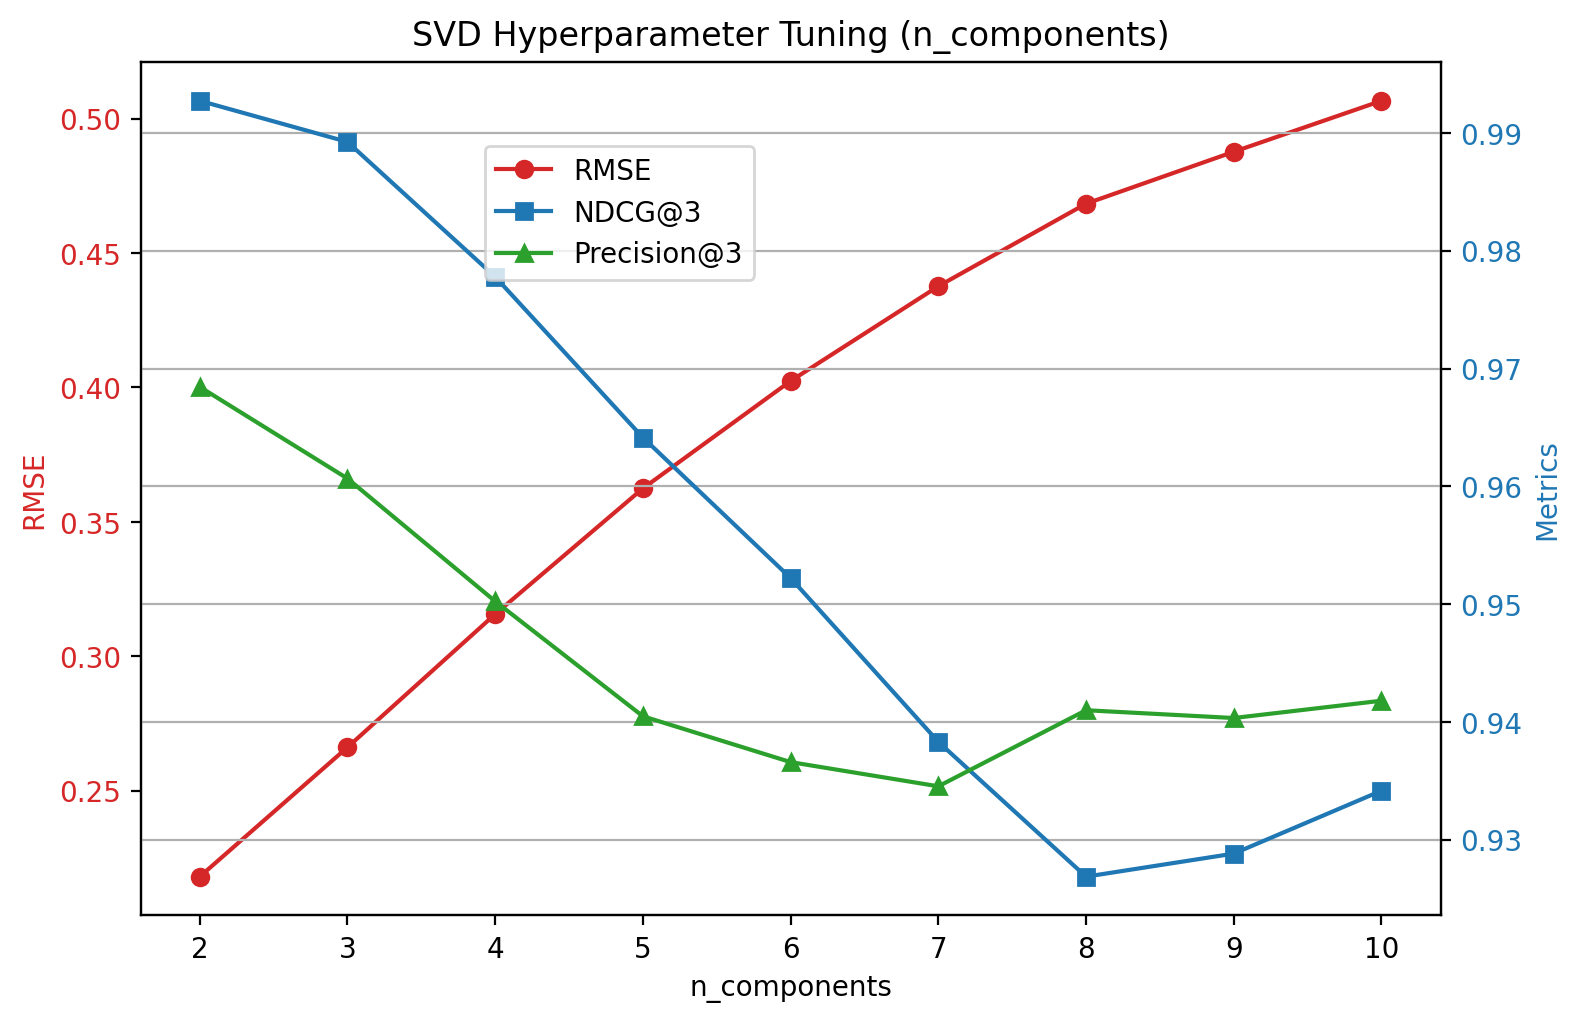

In [18]:
# --- 1. Tune n_components for SVD ---
svd_components_list = [2, 3, 4, 5, 6, 7, 8, 9, 10]
svd_results = []

for n in svd_components_list:
    n_comp = min(n, min(len(all_clients), len(product_meta)) - 1)
    svd_tune = TruncatedSVD(n_components=n_comp, random_state=42)
    latent_users_tune = svd_tune.fit_transform(interaction_train.values)
    latent_items_tune = svd_tune.components_

    svd_tune_scores = pd.DataFrame(
        np.dot(latent_users_tune, latent_items_tune),
        index=interaction_train.index,
        columns=interaction_train.columns,
    )
    svd_tune_scores = apply_business_rules(svd_tune_scores, all_clients, product_meta)

    metrics = evaluate_recommender(
        svd_tune_scores, interaction_matrix, holdout_pairs, k=3
    )
    metrics["n_components"] = n_comp
    svd_results.append(metrics)

svd_results_df = pd.DataFrame(svd_results).drop_duplicates(subset=["n_components"])

# Plot SVD tuning results
fig, ax1 = plt.subplots(figsize=(8, 5))

color = "tab:red"
ax1.set_xlabel("n_components")
ax1.set_ylabel("RMSE", color=color)
ax1.plot(
    svd_results_df["n_components"],
    svd_results_df["RMSE"],
    marker="o",
    color=color,
    label="RMSE",
)
ax1.tick_params(axis="y", labelcolor=color)

ax2 = ax1.twinx()
color = "tab:blue"
ax2.set_ylabel("Metrics", color=color)
ax2.plot(
    svd_results_df["n_components"],
    svd_results_df["NDCG@3"],
    marker="s",
    color="tab:blue",
    label="NDCG@3",
)
ax2.plot(
    svd_results_df["n_components"],
    svd_results_df["Precision@3"],
    marker="^",
    color="tab:green",
    label="Precision@3",
)
ax2.tick_params(axis="y", labelcolor=color)

fig.tight_layout()
plt.title("SVD Hyperparameter Tuning (n_components)")
fig.legend(loc="upper left", bbox_to_anchor=(0.3, 0.9))
plt.grid(True)
# save figure
plt.savefig(FIGURES_DIR / "svd_tuning.png", dpi=300, bbox_inches="tight")
plt.show()

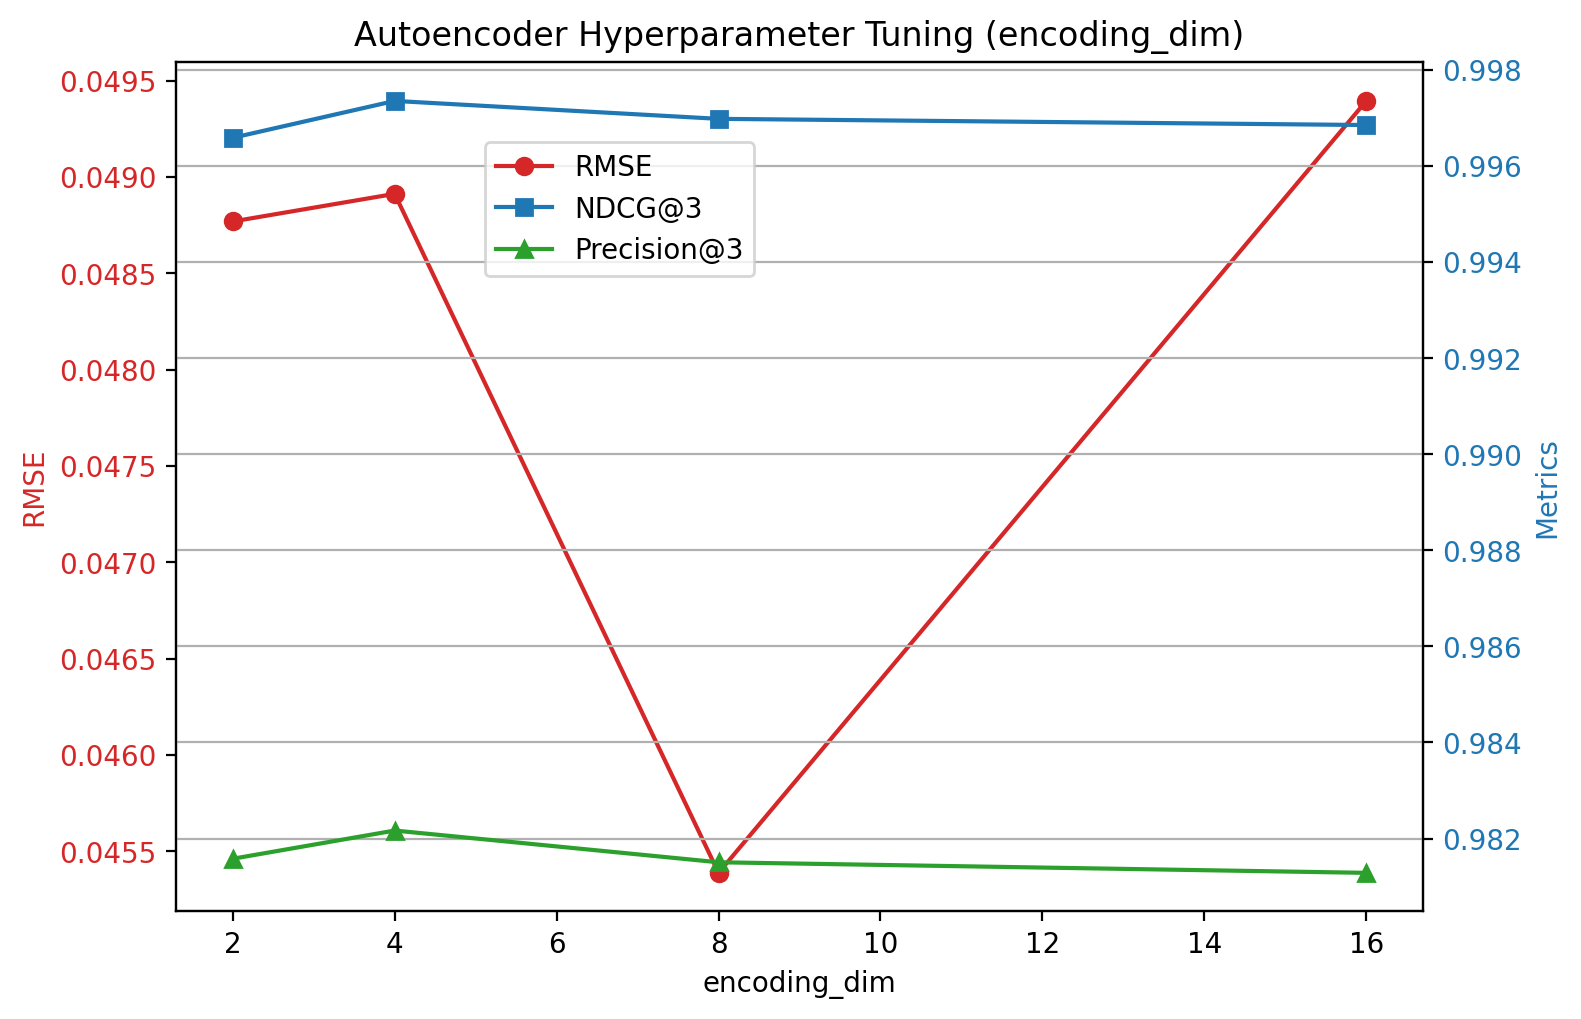

,RMSE,Precision@3,Recall@3,NDCG@3,n_components
0,0.218001,0.968443,0.968443,0.992729,2
1,0.266130,0.960663,0.960663,0.989238,3
2,0.315676,0.950242,0.950242,0.977785,4
3,0.362456,0.940481,0.940481,0.964143,5
4,0.402428,0.936592,0.936592,0.952216,6
5,0.437680,0.934537,0.934537,0.938311,7
6,0.468387,0.940995,0.940995,0.926868,8
7,0.487708,0.940335,0.940335,0.928824,9
8,0.506674,0.941802,0.941802,0.934163,10


,RMSE,Precision@3,Recall@3,NDCG@3,encoding_dim
0,0.048770,0.981579,0.981579,0.996588,2
1,0.048913,0.982166,0.982166,0.997356,4
2,0.045388,0.981506,0.981506,0.996983,8
3,0.049396,0.981286,0.981286,0.996854,16


In [19]:
# --- 2. Tune encoding_dim for Autoencoder ---
encoding_dims = [2, 4, 8, 16]
ae_results = []

for edim in encoding_dims:
    # Quick train
    tune_model = RecommenderAutoencoder(
        n_products=X_val_train.shape[1], encoding_dim=edim
    )
    tune_opt = torch.optim.AdamW(tune_model.parameters(), lr=0.005)

    for epoch in range(30):
        tune_model.train()
        for val_inputs, val_mask in val_loader:
            tune_opt.zero_grad()
            outputs = tune_model(val_inputs)
            loss = masked_mse_loss(outputs, val_inputs, val_mask)
            loss.backward()
            tune_opt.step()

    tune_model.eval()
    with torch.no_grad():
        ae_reconstructed = tune_model(X_val_train).numpy()

    ae_reconstructed_df = pd.DataFrame(
        ae_reconstructed,
        index=interaction_train.index,
        columns=interaction_train.columns,
    )

    metrics = evaluate_recommender(
        ae_reconstructed_df, interaction_matrix, holdout_pairs, k=3
    )
    metrics["encoding_dim"] = edim
    ae_results.append(metrics)

ae_results_df = pd.DataFrame(ae_results)

# Plot Autoencoder tuning results
fig2, ax3 = plt.subplots(figsize=(8, 5))

color = "tab:red"
ax3.set_xlabel("encoding_dim")
ax3.set_ylabel("RMSE", color=color)
ax3.plot(
    ae_results_df["encoding_dim"],
    ae_results_df["RMSE"],
    marker="o",
    color=color,
    label="RMSE",
)
ax3.tick_params(axis="y", labelcolor=color)

ax4 = ax3.twinx()
color = "tab:blue"
ax4.set_ylabel("Metrics", color=color)
ax4.plot(
    ae_results_df["encoding_dim"],
    ae_results_df["NDCG@3"],
    marker="s",
    color="tab:blue",
    label="NDCG@3",
)
ax4.plot(
    ae_results_df["encoding_dim"],
    ae_results_df["Precision@3"],
    marker="^",
    color="tab:green",
    label="Precision@3",
)
ax4.tick_params(axis="y", labelcolor=color)

fig2.tight_layout()
plt.title("Autoencoder Hyperparameter Tuning (encoding_dim)")
fig2.legend(loc="upper left", bbox_to_anchor=(0.3, 0.9))
plt.grid(True)
# save figure
plt.savefig(FIGURES_DIR / "autoencoder_tuning.png", dpi=300, bbox_inches="tight")
plt.show()

display(svd_results_df)
display(ae_results_df)


SVD (Linear & Unprotected): SVD is a linear algorithm. Increasing n_components forces it to capture random noise in the data. Because it lacks built-in regularization, this quickly leads to overfitting, causing its performance to drop on unseen data.

Autoencoder (Non-linear & Protected): An autoencoder is a deep neural network. Increasing the encoding_dim expands its capacity to learn complex, non-linear patterns. It avoids overfitting because we apply strong regularization (Denoising, Dropout, and Weight Decay), which forces the model to learn genuine relationships rather than just memorizing the training set.
